# CRDA Demo: Counterfactual Residual Data Augmentation

This notebook demonstrates the Counterfactual Residual Data Augmentation (CRDA) methodology using the Energy Efficiency dataset. CRDA is a technique that improves machine learning model performance by augmenting training data with causally-informed synthetic examples.

## Overview
The demo compares baseline models (MLP and XGBoost) with their CRDA-augmented versions on energy efficiency prediction tasks. The process involves:

1. **Feature Selection**: Identifying features that are uncorrelated with model residuals and not causally connected to the target
2. **Data Augmentation**: Creating synthetic examples by perturbing selected features
3. **Model Training**: Training augmented models and comparing performance
4. **Evaluation**: Statistical comparison using Wilcoxon signed-rank tests

## Setup and Imports

First, we import the necessary modules from the CRDA framework:
- `Config`: Configuration management for experiments
- `Logger`: Logging functionality for tracking experiment progress
- `Experiment`: Main class that orchestrates the CRDA methodology

In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

from src.utils.config import Config
from src.utils.logger import Logger
from src.experiment import Experiment


/CRDA/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Experiment 1: MLP Baseline with Conservative Augmentation

We start with a Multi-Layer Perceptron (MLP) baseline using conservative augmentation parameters:

- **Dataset**: Energy Efficiency dataset (`EnergyEfficiency.csv`)
- **Augmentation Parameters**:
  - `max_n_features_to_perturb=1`: Only perturb one feature at a time
  - `max_perturb_percent=0.2`: Maximum 20% increase in feature values
  - `min_perturb_percent=-0.2`: Maximum 20% decrease in feature values
  - `aug_data_size_factor=1.0`: Generate same amount of augmented data as original

This conservative approach helps us understand the baseline performance improvement with minimal feature perturbation.

In [2]:
mlp_config = Config(
    baseline="mlp",
    dataset_path="../data/EnergyEfficiency.csv",
    results_dir="../demo/EnergyEfficiency",
    num_seeds=1,
    save_params=True,
    save_models=True,
    save_plots=True,
    aug_data_size_factor=1.0,
    max_n_features_to_perturb=1,
    max_perturb_percent=0.2,
    min_perturb_percent=-0.2,
    aug_data_weight=1.0,
)

### Running the MLP Experiment

The experiment will:
1. Load and split the Energy Efficiency dataset
2. Train a baseline MLP model
3. Calculate residuals and identify candidate features for perturbation
4. Create a causal graph to understand feature relationships
5. Filter features that are uncorrelated with residuals and causally independent
6. Generate augmented training data by perturbing the selected feature(s)
7. Train an augmented model and compare performance

**Key Results to Watch:**
- **Feature Selection**: Which feature gets selected for perturbation
- **Performance Improvement**: Comparison between original and augmented MSE
- **Statistical Significance**: Wilcoxon signed-rank test p-value

2025-05-23 03:36:52 - INFO - Experiment initialized with config:
Experiment Config (Name: mlp_20250523-033652)
  timestamp: 20250523-033652
  dataset_path: ../data/EnergyEfficiency.csv
  dataset_dir_path: None
  baseline: mlp
  aug_data_size_factor: 1.0
  max_n_features_to_perturb: 1
  max_perturb_percent: 0.2
  min_perturb_percent: -0.2
  aug_data_weight: 1.0
  alpha: 0.05
  r_corr_threshold: 0.1
  p_corr_threshold: 0.05
  test_size: 0.2
  random_seed: 0
  num_seeds: 1
  p_wilcoxon_threshold: 0.05
  hyperparam_tune: False
  sample_sizes: None
  ignore_filter: False
  results_dir: ../demo/EnergyEfficiency
  save_plots: True
  save_models: True
  save_params: True
  experiment_dir: ../demo/EnergyEfficiency/mlp_20250523-033652
2025-05-23 03:36:52 - INFO - Loaded 1 datasets


2025-05-23 03:36:52 - INFO - 






****************************************************************************************************
2025-05-23 03:36:52 - INFO - Running experiment on dataset: EnergyEfficiency
20

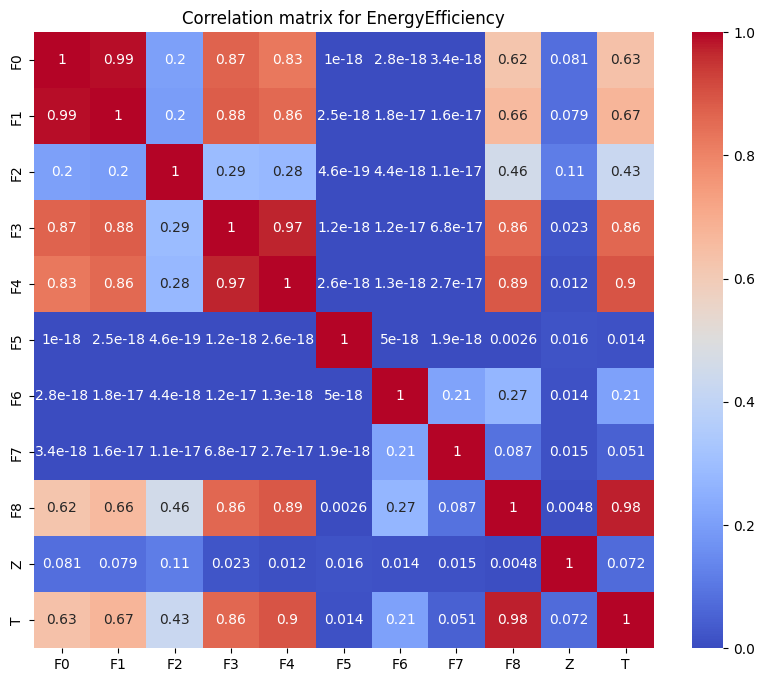

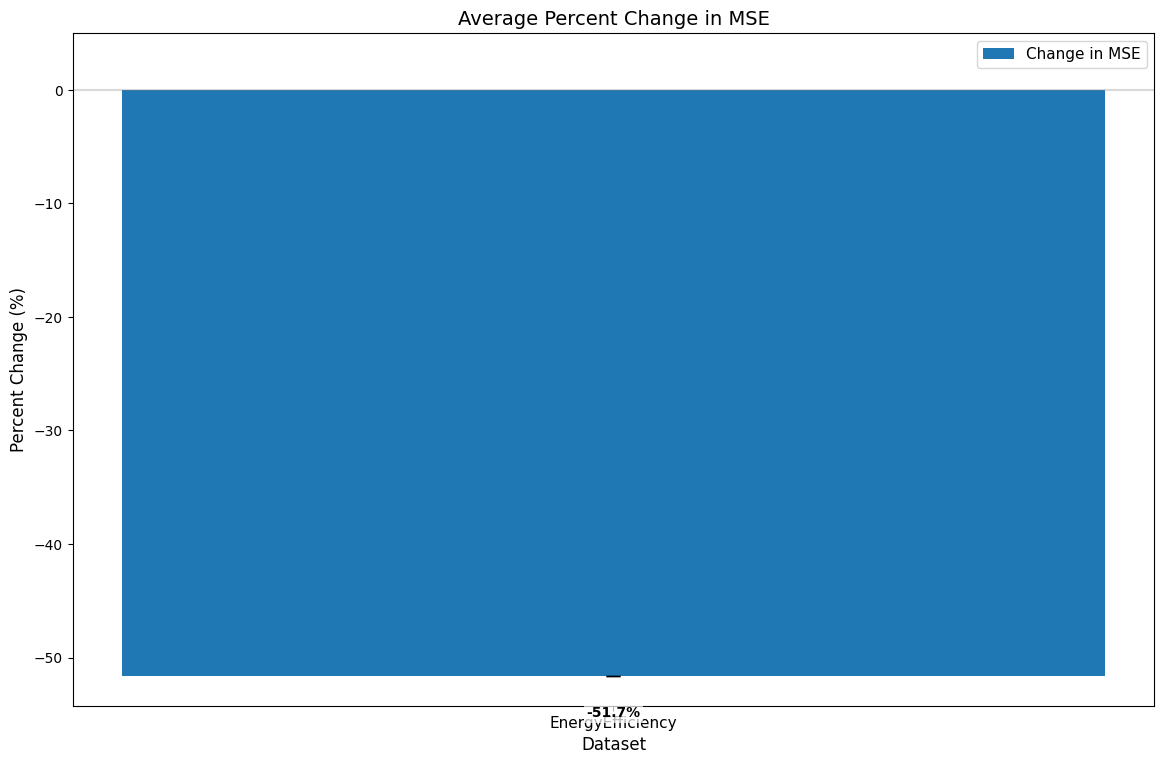

In [3]:
mlp_experiment = Experiment(mlp_config, Logger())
mlp_experiment.run()
mlp_experiment.plot_results()

### MLP Results Analysis

**Key Findings:**
- **Selected Feature**: F8 was chosen for perturbation (highest score: 0.971)
- **Performance Improvement**: ~51.7% reduction in MSE (from 0.00132 to 0.00064)
- **Statistical Significance**: p-value = 0.00098 < 0.05 (highly significant)
- **Feature Characteristics**: F8 has strong correlation with target (r=0.976) but weak correlation with residuals (r=-0.005)

The CRDA methodology successfully identified F8 as an ideal candidate for augmentation because it's predictive of the target but not correlated with model errors, making it safe to perturb without introducing bias.

## Experiment 2: XGBoost with Aggressive Augmentation

Now we test XGBoost with more aggressive augmentation parameters:

- **Model**: XGBoost (gradient boosting)
- **Augmentation Parameters**:
  - `max_n_features_to_perturb=5`: Perturb up to 5 features simultaneously
  - `max_perturb_percent=0.9`: Maximum 90% increase in feature values
  - `min_perturb_percent=-0.9`: Maximum 90% decrease in feature values

This aggressive approach tests whether tree-based models can benefit from larger perturbations and multi-feature interventions.

In [4]:
xgb_config = Config(
    baseline="xgboost",
    dataset_path="../data/EnergyEfficiency.csv",
    results_dir="../demo/EnergyEfficiency",
    num_seeds=1,
    save_params=True,
    save_models=True,
    save_plots=True,
    aug_data_size_factor=1.0,
    max_n_features_to_perturb=5,
    max_perturb_percent=0.9,
    min_perturb_percent=-0.9,
    aug_data_weight=1.0,
)

### Running the XGBoost Experiment

This experiment follows the same methodology but with different model architecture and perturbation strategy:

**Expected Differences:**
- **Feature Selection**: XGBoost may identify different features due to different residual patterns
- **Multiple Features**: Up to 5 features may be selected for simultaneous perturbation
- **Larger Perturbations**: ±90% changes test robustness to extreme variations
- **Tree-based Handling**: XGBoost's ensemble nature may handle larger perturbations differently than neural networks

2025-05-23 03:36:59 - INFO - Experiment initialized with config:
Experiment Config (Name: xgboost_20250523-033659)
  timestamp: 20250523-033659
  dataset_path: ../data/EnergyEfficiency.csv
  dataset_dir_path: None
  baseline: xgboost
  aug_data_size_factor: 1.0
  max_n_features_to_perturb: 5
  max_perturb_percent: 0.9
  min_perturb_percent: -0.9
  aug_data_weight: 1.0
  alpha: 0.05
  r_corr_threshold: 0.1
  p_corr_threshold: 0.05
  test_size: 0.2
  random_seed: 0
  num_seeds: 1
  p_wilcoxon_threshold: 0.05
  hyperparam_tune: False
  sample_sizes: None
  ignore_filter: False
  results_dir: ../demo/EnergyEfficiency
  save_plots: True
  save_models: True
  save_params: True
  experiment_dir: ../demo/EnergyEfficiency/xgboost_20250523-033659
2025-05-23 03:36:59 - INFO - Loaded 1 datasets


2025-05-23 03:36:59 - INFO - 






****************************************************************************************************
2025-05-23 03:36:59 - INFO - Running experiment on dataset: EnergyE

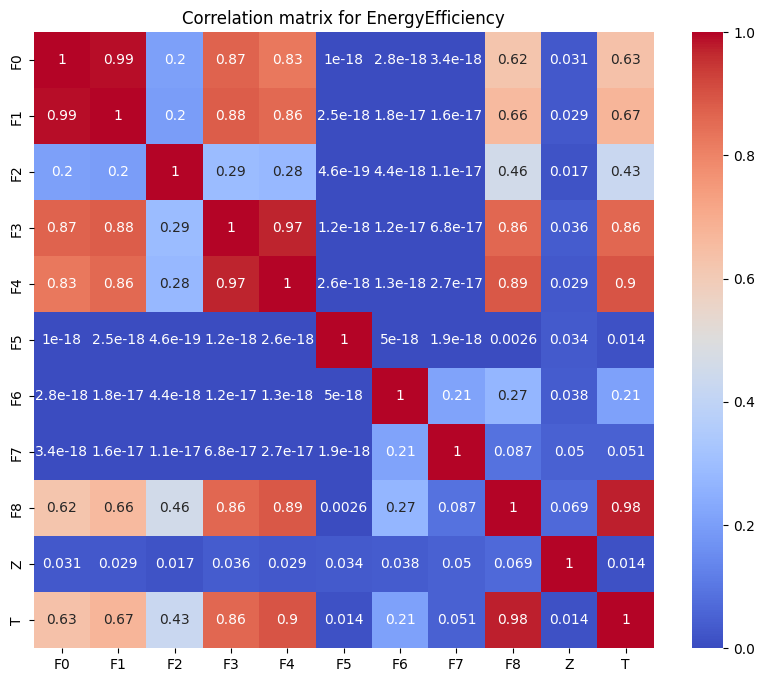

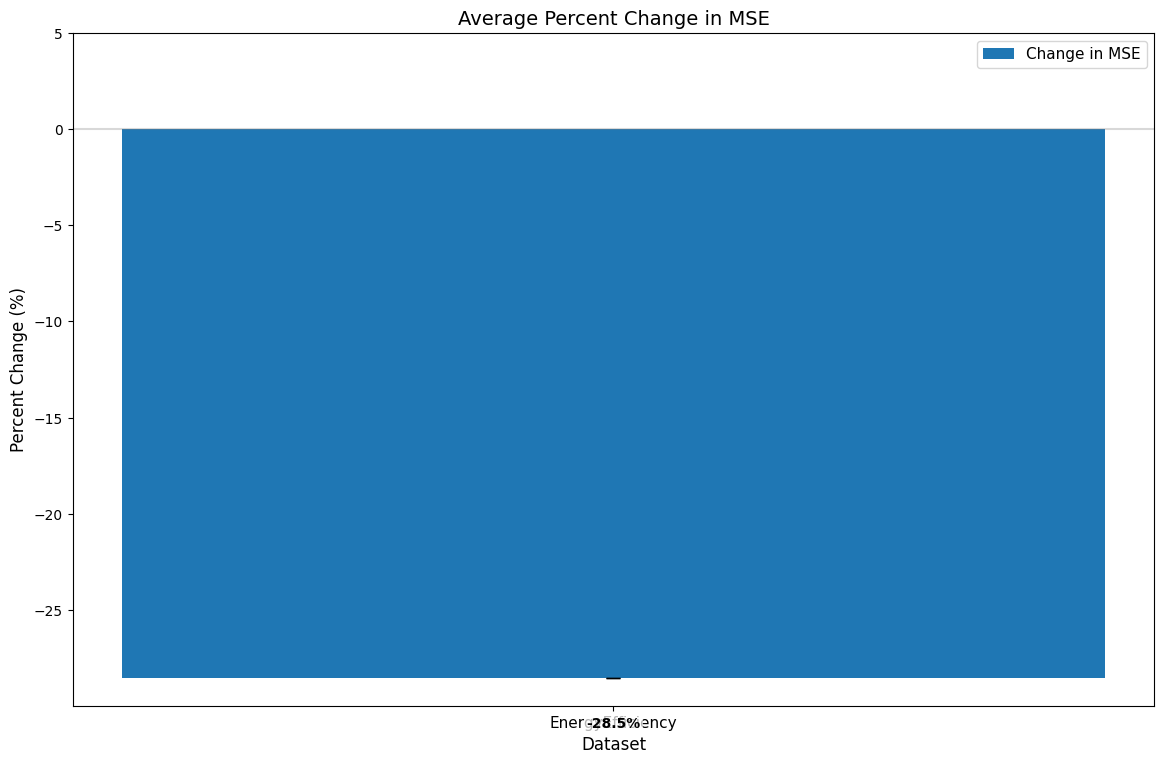

In [5]:
xgb_experiment = Experiment(xgb_config, Logger())
xgb_experiment.run()
xgb_experiment.plot_results()

### XGBoost Results Analysis

**Key Findings:**
- **Selected Features**: F8, F4, F3, F1, F0 (5 features selected for simultaneous perturbation)
- **Performance Improvement**: ~28.6% reduction in MSE (from 0.00130 to 0.00093)
- **Statistical Significance**: p-value = 0.042 < 0.05 (significant)
- **Feature Rankings**: Same top features as MLP but with different correlation patterns

**Comparison with MLP:**
- **Improvement Magnitude**: MLP achieved larger improvement (51.7% vs 28.6%)
- **Feature Strategy**: XGBoost used 5 features vs MLP's 1 feature
- **Perturbation Range**: XGBoost tolerated ±90% vs MLP's ±20%
- **Statistical Power**: Both achieved significance, but MLP had stronger p-value

## Conclusions

This demo illustrates that CRDA can improve both neural network and tree-based models, with the optimal strategy depending on model architecture:

1. **Conservative vs Aggressive**: Sometimes conservative perturbations (MLP) outperform aggressive ones (XGBoost)
2. **Feature Selection**: Both models identified F8 as the top candidate, validating the methodology
3. **Model-Specific Patterns**: Different models may benefit from different augmentation strategies
4. **Causal Safety**: The framework successfully avoided features that could introduce bias

The generated outputs include causal graphs, correlation matrices, model parameters, and performance plots for further analysis.